In [1]:
# Imports
## Basic imports
import numpy as np
import xarray as xr
import utils

## Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Optimization
from scipy.optimize import curve_fit

## Setup plot defaults
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

# Create all train/test scenarios

### 1. Traditional scenarios (single-forcing surrogate)
1. SSP585
2. SSP119
3. Abrupt

### 2. Idealized scenarios
TBD

### 3. Test scenarios
TBD

In [2]:
forcing_ssp585_path = 'data/MPI/historical_ssp/historical_ssp585_ERF_global_anomaly.nc4'
forcing_ssp585_ds = xr.open_dataset(forcing_ssp585_path)
forcing_ssp585_np = forcing_ssp585_ds.ERF.values

In [24]:
forcings = {}

In [25]:
def exponential_fit(x, a, b, c):
  return a * np.exp(b * x) + c

t_vec = np.arange(0, len(forcing_ssp585_np))
popt, pcov = curve_fit(exponential_fit, t_vec, forcing_ssp585_np, p0=[1, 0.01, -1])
a_fit, b_fit, c_fit = popt
forcing_ssp585_fit = exponential_fit(t_vec, a_fit, b_fit, c_fit)
forcings['ssp585'] = forcing_ssp585_fit

In [32]:
forcing_ssp119_path = 'data/MPI/historical_ssp_smooth/historical_ssp119_ERF_global_anomaly_smooth'
forcing_ssp119_np = utils.open_results(forcing_ssp119_path)

In [50]:
from scipy.special import erfc

def emg_func(x, amplitude, center, sigma, tau):
  """Exponentially Modified Gaussian (EMG) function."""
  z = (sigma**2 / (2 * tau**2) - (x - center) / tau) / (sigma * np.sqrt(2))
  return (amplitude * sigma / tau) * np.sqrt(np.pi / 2) * np.exp(0.5 * (sigma / tau)**2 - (x - center) / tau) * erfc(z)

def quartic_func(x, a, b, c, d, e):
  """A 4th-degree polynomial function."""
  return a * x**4 + b * x**3 + c * x**2 + d * x + e

popt, pcov = curve_fit(quartic_func, t_vec, forcing_ssp119_np)
a_fit, b_fit, c_dit, d_fit, e_fit = popt
forcing_ssp119_fit = quartic_func(t_vec, a_fit, b_fit, c_dit, d_fit, e_fit)
forcings['ssp119'] = forcing_ssp119_fit

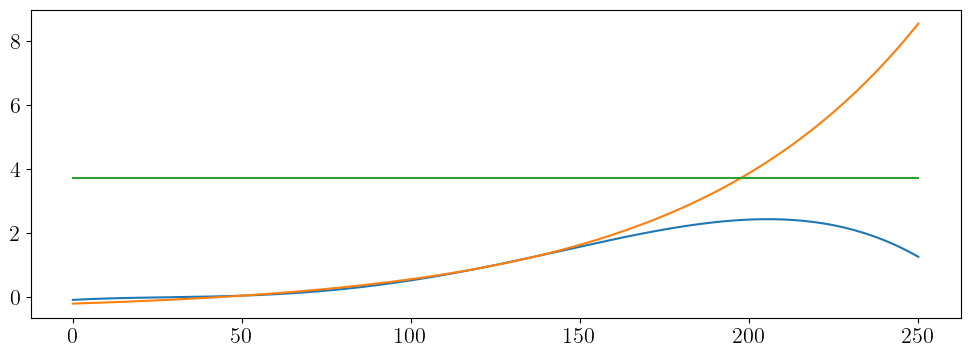

In [56]:
#plt.plot(forcing_ssp119_np)
plt.plot(forcing_ssp119_fit)
plt.plot(forcing_ssp585_fit)
plt.plot(forcings['abrupt'])

In [53]:
forcings['abrupt'] = 3.7*np.ones(len(forcing_ssp119_fit))

In [62]:
from scipy.signal import max_len_seq

def generate_prbs_scipy(length, n_bits=7, levels=(-1, 1)):
    """
    Generates a PRBS using scipy.signal.max_len_seq.

    Args:
        length (int): The desired length of the output sequence.
        n_bits (int): The number of bits in the shift register.
        levels (tuple): A tuple of two numbers (low, high) for the output.

    Returns:
        np.ndarray: The generated PRBS signal.
    """
    # Generate the maximal-length sequence (returns 1s and 2s)
    # The full sequence length is 2**n_bits - 1
    m_seq = max_len_seq(n_bits)[0]

    # Truncate or repeat the sequence to match the desired length
    if length > len(m_seq):
        # Tile the sequence if the desired length is longer than one period
        repeats = int(np.ceil(length / len(m_seq)))
        prbs_binary = np.tile(m_seq, repeats)[:length]
    else:
        prbs_binary = m_seq[:length]

    # Scipy's function outputs 1s and 2s, so we map them to the desired levels
    low, high = levels
    # Map 1 -> low, 2 -> high
    prbs_signal = np.where(prbs_binary == 1, low, high)

    return prbs_signal

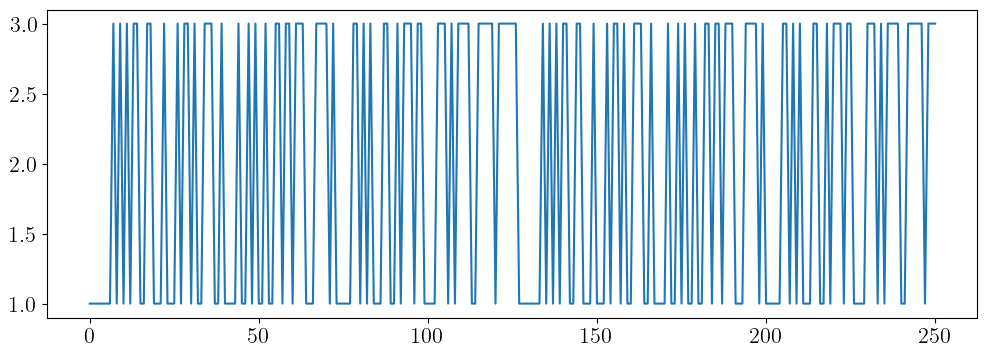

In [165]:
forcing_prbs = generate_prbs_scipy(251, n_bits=7, levels=(1, 3))
forcings['prbs'] = forcing_prbs
plt.plot(forcing_prbs)

In [79]:
def generate_multisine(time_vector, amplitudes, frequencies, phases=None):
    """
    Generates a multisine signal.

    A multisine signal is the sum of a number of sinusoids at specified
    frequencies, amplitudes, and phases.

    Args:
        time_vector (np.ndarray): A 1D NumPy array representing the time points
                                  at which to calculate the signal.
        amplitudes (list or np.ndarray): A list or array of the amplitude
                                         for each sine wave.
        frequencies (list or np.ndarray): A list or array of the frequency (in Hz)
                                          for each sine wave. Must be the same
                                          length as amplitudes.
        phases (list or np.ndarray, optional): A list or array of the phase
                                               (in radians) for each sine wave.
                                               If None, all phases are set to zero.
                                               Defaults to None.

    Returns:
        np.ndarray: A NumPy array of the same length as time_vector containing
                    the multisine signal.

    Raises:
        ValueError: If the lengths of amplitudes and frequencies do not match.
    """
    amplitudes = np.asarray(amplitudes)
    frequencies = np.asarray(frequencies)

    if len(amplitudes) != len(frequencies):
        raise ValueError("Amplitudes and frequencies must have the same length.")

    if phases is None:
        # If no phases are provided, use zeros.
        phases = np.zeros_like(amplitudes)
    else:
        phases = np.asarray(phases)
        if len(phases) != len(amplitudes):
            raise ValueError("Phases must have the same length as amplitudes and frequencies.")

    # Ensure time_vector is a column vector for broadcasting
    t = time_vector[:, np.newaxis]
    
    # Angular frequencies (2 * pi * f)
    omegas = 2 * np.pi * frequencies
    
    # Create a matrix of sine waves: each column is a sine wave for a given frequency
    # Broadcasting takes care of applying each frequency and amplitude to the time vector
    # Resulting shape: (len(time_vector), len(frequencies))
    sine_waves = amplitudes * np.sin(omegas * t + phases)
    
    # Sum along the columns to get the final multisine signal
    multisine_signal = np.sum(sine_waves, axis=1)
    
    return multisine_signal

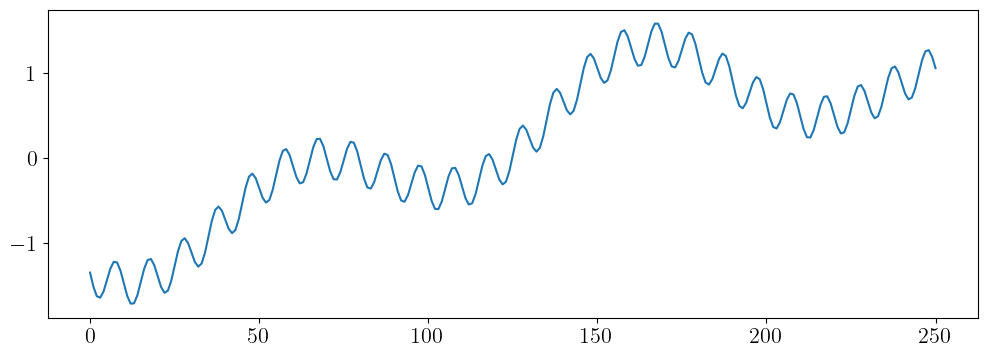

In [97]:
amps = [-1.0, -0.5, -0.25]         # Amplitudes of the sine waves
freqs = [0.0025, 0.01, 0.1]             # Frequencies in Hz
phases = [np.pi/2, np.pi/4, 0]

# 2. Generate the multisine signal
multisine1 = generate_multisine(t_vec, amps, freqs, phases)
forcings['multisine'] = multisine1
plt.plot(multisine1)

In [105]:
from scipy.signal import chirp

def generate_step(time_vector, step_time=0.0, level_pre=0.0, level_post=1.0):
  """Generates a step signal."""
  signal = np.full_like(time_vector, level_pre)
  signal[time_vector >= step_time] = level_post
  return signal

def generate_impulse(time_vector, impulse_time=0.0, amplitude=1.0):
  """Generates an impulse signal (approximated as a single-point pulse)."""
  signal = np.zeros_like(time_vector)
  # Find the index closest to the desired impulse time
  impulse_idx = np.abs(time_vector - impulse_time).argmin()
  signal[impulse_idx] = amplitude
  return signal + 1

def generate_chirp(time_vector, f_start=1.0, f_end=25.0, method='linear'):
  """Generates a chirp (swept-frequency) signal."""
  # Ensure time starts at 0 for scipy's chirp function if not already
  t_start = time_vector[0]
  t_end = time_vector[-1]
  # Scipy's chirp function requires the time points, end time, start freq, and end freq
  return chirp(time_vector, f0=f_start, f1=f_end, t1=t_end, method=method)

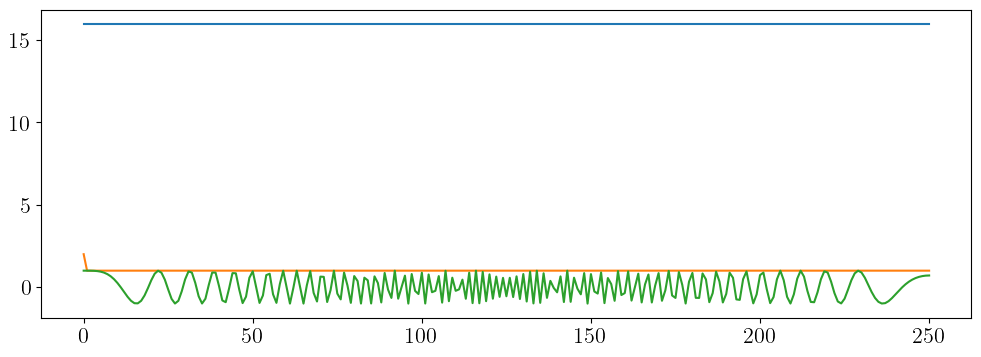

In [190]:
forcing_step = generate_step(t_vec, step_time = 0, level_pre=0.0,level_post=16.0)
forcing_pulse = generate_impulse(t_vec, impulse_time=0, amplitude=1.0)
forcing_chirp = generate_chirp(t_vec, f_start = 0.001, f_end = 1)
forcings['step'] = forcing_step
forcings['pulse'] = forcing_pulse
forcings['chirp'] = forcing_chirp
plt.plot(forcing_step)
plt.plot(forcing_pulse)
plt.plot(forcing_chirp)

# Calculate information criteria

### 1. DMD criteria

In [137]:
w = {}
scenarios = ['ssp585','ssp119','abrupt','prbs','multisine','step','pulse','chirp']
lam = 1.3
C = 4.6
for scenario in scenarios:
  w[scenario] = np.zeros(len(t_vec))

  for t in t_vec[1:]:
    w[scenario][t] = w[scenario][t - 1] + (-lam*w[scenario][t - 1] + forcings[scenario][t-1])/C

In [141]:
scenario = 'ssp585'
theta = np.concatenate([w[scenario],forcings[scenario]])

In [145]:
print(w[scenario][0:5],forcings[scenario][0:5])

[ 0.         -0.04684341 -0.07971381 -0.10254922 -0.11817458] [-0.21547969 -0.21210027 -0.20867083 -0.20519066 -0.20165899]


In [151]:
F_DMD = compute_Fisher_full_DMD(w[scenario], forcings[scenario], 2, 1)

In [168]:
def compute_Fisher_individual_DMD(w, u, sigma):
  return np.outer(w, u) / sigma**2

def compute_Fisher_full_DMD(w, u, n, sigma):
  k = len(w)
  F_full = np.zeros((n, n))
  for t in range(k - 2):
    F_full += compute_Fisher_individual_DMD(w[t:t + 2], u[t + 2], sigma)

  return F_full

In [189]:
A_DMD, D_DMD, E_DMD = {}, {}, {}
sigma = 1
n = 2
Fisher_DMD = {}
print(f'Testing Optimal Design Criteria\n')
for scenario in scenarios:
  print(f'Scenario - {scenario}')
  Fisher_DMD[scenario] = compute_Fisher_full_DMD(w[scenario], forcings[scenario], n, sigma)
  A_DMD[scenario], D_DMD[scenario], E_DMD[scenario] = utils.get_optimality_conditions(Fisher_DMD[scenario], sigma)

Testing Optimal Design Criteria

Scenario - ssp585
	A optimality - minimize 14754958611664.807
	D optimality - maximize SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(-22.2304737793956))
	E optimality - maximize -2.2737367544323206e-13
Scenario - ssp119
	A optimality - minimize 296597566639961.9
	D optimality - maximize SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(-26.68543227986768))
	E optimality - maximize 0.0
Scenario - abrupt
	A optimality - minimize 16278537100749.49
	D optimality - maximize SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(-21.868244882404817))
	E optimality - maximize 0.0
Scenario - prbs
	A optimality - minimize 42755354262930.28
	D optimality - maximize SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(-24.083142983441654))
	E optimality - maximize 0.0
Scenario - multisine
	A optimality - minimize 207987049699118.2
	D optimality - maximize SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(-27.441589788484066))
	E opti

### 2. Deconvolution criteria

In [191]:
A_deconv, D_deconv, E_deconv = {}, {}, {}
sigma = 1
Fisher_deconv = {}
print(f'Testing Optimal Design Criteria\n')
for scenario in scenarios:
  print(f'Scenario - {scenario}')
  Fisher_deconv[scenario] = utils.compute_Fisher_full(forcings[scenario], sigma)
  A_deconv[scenario], D_deconv[scenario], E_deconv[scenario] = utils.get_optimality_conditions(Fisher_deconv[scenario], sigma)

Testing Optimal Design Criteria

Scenario - ssp585
	A optimality - minimize 14875.436725224725
	D optimality - maximize SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(-770.5140804926685))
	E optimality - maximize 0.0002349985621415251
Scenario - ssp119
	A optimality - minimize 4736676.319395786
	D optimality - maximize SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(-1158.6033880741945))
	E optimality - maximize 2.1327283195352315e-07
Scenario - abrupt
	A optimality - minimize 36.59605551497454
	D optimality - maximize SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(656.7830754643888))
	E optimality - maximize 3.422633511454645
Scenario - prbs
	A optimality - minimize 7619486040765528.0
	D optimality - maximize SlogdetResult(sign=np.float64(-1.0), logabsdet=np.float64(330.5491414799884))
	E optimality - maximize (-1.3750366180557479e-14+0j)
Scenario - multisine
	A optimality - minimize 313.11877818564346
	D optimality - maximize SlogdetResult(sign=np.float64